In [2]:
pip install -U -q "langchain[google-genai]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.4/236.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.2/121.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 4.7 MB/s eta 0:00:00


In [18]:
%pip install -q pygraphviz==1.14

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.0/106.0 kB 4.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for pygraphviz (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pygraphviz
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pygraphviz)


In [5]:
from langgraph.graph import StateGraph, END,START
from typing import TypedDict
from pydantic import BaseModel, Field

In [1]:
def print_workflow_info(workflow, app=None):
    """Prints comprehensive information about a LangGraph workflow."""
    print("WORKFLOW INFORMATION")
    print("====================")
    print(f"Nodes: {workflow.nodes}")
    print(f"Edges: {workflow.edges}")


    # Use getter method for finish points if available
    try:
        finish_points = workflow.finish_points
        print(f"Finish points: {finish_points}")
    except:
        try:
            # Alternative approaches
            print(f"Finish point: {workflow._finish_point}")
        except:
            print("Finish points attribute not directly accessible")

    if app:
        print("\nWorkflow Visualization:")
        from IPython.display import display
        display(app.get_graph().draw_png())

In [3]:
import os
from langchain.chat_models import init_chat_model
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

model = init_chat_model(
    model="gemini-2.5-flash",
    model_provider="google_genai"
)

### Prompt Chaining

Prompt Chaining is a workflow design pattern where complex tasks are decomposed into a sequence of LLM (Large Language Model) calls. Each step depends on the output of the previous one, allowing for step-by-step refinement or evolution of the data being processed. This method mirrors how humans tackle multifaceted problems—by breaking them down into manageable steps.

It leverages **function calling**, **sequential chaining** and or **AI Agents** , often implemented using frameworks such as **LangChain**, **LangGraph**, or even custom scripts. The key is modularity and clarity—each node (or step) has a specific role in the overall pipeline. Each link in the chain is a tool call or Agent the structure of which is something like the following:

#### Typical Structure:
- **Step 1:** Initial LLM prompt (for example, generate a draft)
- **Step 2:** Refinement prompt (for example, improve style, tone)
- **Step 3:** Evaluation or formatting (for example, convert to specific format or assess quality)

This pattern also allows injecting **external tools** between steps (for example, validation, summarization, keyword extraction).

---

#### Use Cases:
- Generating blog posts or marketing copy step-by-step (idea → outline → paragraph → polish)
- Automated report generation (for example, extract → analyze → summarize)
- Educational content creation (for example, topic → questions → answers → explanations)

---


### Use Case: Prompt Chaining — Job Application Assistant

In this workflow, we are going to build a simple **job application assistant** using the Prompt Chaining pattern. The goal is to help a user create a **personalized cover letter** from a given job description.

We will break the task into two sequential steps:
1. First, the LLM will read the **job description** and generate a **resume summary** tailored to that role.
2. Then, using this summary, the LLM will generate a professional **cover letter** suitable for submitting with a job application.


In [6]:
class ChainState(TypedDict):
    job_description: str
    resume_summary: str
    cover_letter: str

### Resume Summary Agent

In LLM workflows, an "agent" is created through a prompt that gives the LLM specific instructions and persona. The generate_resume_summary node demonstrates this by transforming the LLM into a "resume assistant" through its prompt. This node receives the state containing the job description, processes it using the agent created by the prompt, and returns an updated state with the new resume summary.
Nodes provide the workflow structure while prompts define agent capabilities. The state object serves as shared memory between nodes, allowing each agent to build upon previous work while using the same underlying LLM instance.


In [7]:
def generate_resume_summary(state: ChainState) -> ChainState:
    prompt = f"""
You're a resume assistant. Read the following job description and summarize the key qualifications and experience the ideal candidate should have, phrased as if from the perspective of a strong applicant's resume summary.

Job Description:
{state['job_description']}
"""

    response = model.invoke(prompt)

    return {**state, "resume_summary": response.content}

### Generate Cover Letter Agent


The ```generate_cover_letter``` node defines our second agent in the workflow. This function creates a specialized agent through its prompt This agent accesses both ```state['resume_summary']``` and ```state['job_description'] ```from the current state, leveraging both the output from the previous agent and the original input. The prompt transforms the LLM into a cover letter specialist that synthesizes these elements into a tailored application document. The agent's output is then added to the state dictionary under the ```cover_letter``` key, completing the workflow chain with a state object containing all three key elements.


In [8]:
def generate_cover_letter(state: ChainState) -> ChainState:
    prompt = f"""
You're a cover letter writing assistant. Using the resume summary below, write a professional and personalized cover letter for the following job.

Resume Summary:
{state['resume_summary']}

Job Description:
{state['job_description']}
"""

    response = model.invoke(prompt)

    return {**state, "cover_letter": response.content}

## LangGraph Workflow
### Initializing the LangGraph Workflow



This line creates a new `StateGraph` instance and configures it with our `ChainState` definition. This crucial step establishes the workflow's foundation by specifying the structure of data that will flow through the nodes. The `StateGraph` uses the `ChainState` TypedDict to validate data types for each field (`job_description`, `resume_summary`, and `cover_letter`), ensuring proper information passing between nodes. This data contract enables LangGraph to manage state transitions efficiently as the workflow progresses from node to node.


In [10]:
workflow = StateGraph(ChainState)
workflow

In [11]:
workflow.add_node("generate_resume_summary", generate_resume_summary)
workflow.add_node("generate_cover_letter", generate_cover_letter)

In [12]:
workflow.set_entry_point("generate_resume_summary")

In [13]:
workflow.add_edge("generate_resume_summary", "generate_cover_letter")

In [14]:
workflow.set_finish_point("generate_cover_letter")

In [15]:
print_workflow_info(workflow)

WORKFLOW INFORMATION
Nodes: {'generate_resume_summary': StateNodeSpec(runnable=generate_resume_summary(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.ChainState'>, retry_policy=None, cache_policy=None, is_error_handler=False, error_handler_node=None, ends=(), defer=False, timeout=None), 'generate_cover_letter': StateNodeSpec(runnable=generate_cover_letter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.ChainState'>, retry_policy=None, cache_policy=None, is_error_handler=False, error_handler_node=None, ends=(), defer=False, timeout=None)}
Edges: {('__start__', 'generate_resume_summary'), ('generate_cover_letter', '__end__'), ('generate_resume_summary', 'generate_cover_letter')}
Finish points attribute not directly accessible


In [16]:
app = workflow.compile()

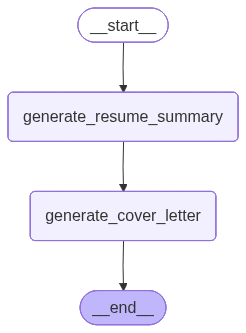

In [21]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [22]:
input_state = {
        "job_description": "We are looking for a data scientist with experience in machine learning, NLP, and Python. Prior work with large datasets and experience deploying models into production is required."
}

result = app.invoke(input_state)

In [23]:
result['resume_summary']

'Here\'s a resume summary from the perspective of a strong applicant:\n\n"Highly accomplished Data Scientist proficient in machine learning and Natural Language Processing (NLP), with a strong command of Python. Possessing proven expertise in analyzing and extracting insights from large datasets, I have a strong track record of successfully deploying robust machine learning models into production environments."'